# EDA: comparing 2012 and 2016

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/VOTER_Survey_December16_Release1.csv', low_memory=False)
df_clean = df[['obamaapp_baseline','obamaapp_2016','presvote16post_2016','envwarm_baseline','envwarm_2016']].dropna()

# simplify Obama approval
def simplify_obama(val):
    if 'Approve' in str(val): return 'Approve'
    if 'Disapprove' in str(val): return 'Disapprove'
    return 'Not Sure'

df_clean['obama_2012'] = df_clean['obamaapp_baseline'].apply(simplify_obama)
df_clean['obama_2016'] = df_clean['obamaapp_2016'].apply(simplify_obama)

# simplify env
def simplify_env(val):
    if 'Definitely is happening' in str(val): return 'Definitely happening'
    if 'Probably is happening' in str(val): return 'Probably happening'
    if 'Probably is not' in str(val): return 'Probably not'
    if 'Definitely is not' in str(val): return 'Definitely not'
    return 'Not Sure'

df_clean['env_2012'] = df_clean['envwarm_baseline'].apply(simplify_env)
df_clean['env_2016'] = df_clean['envwarm_2016'].apply(simplify_env)

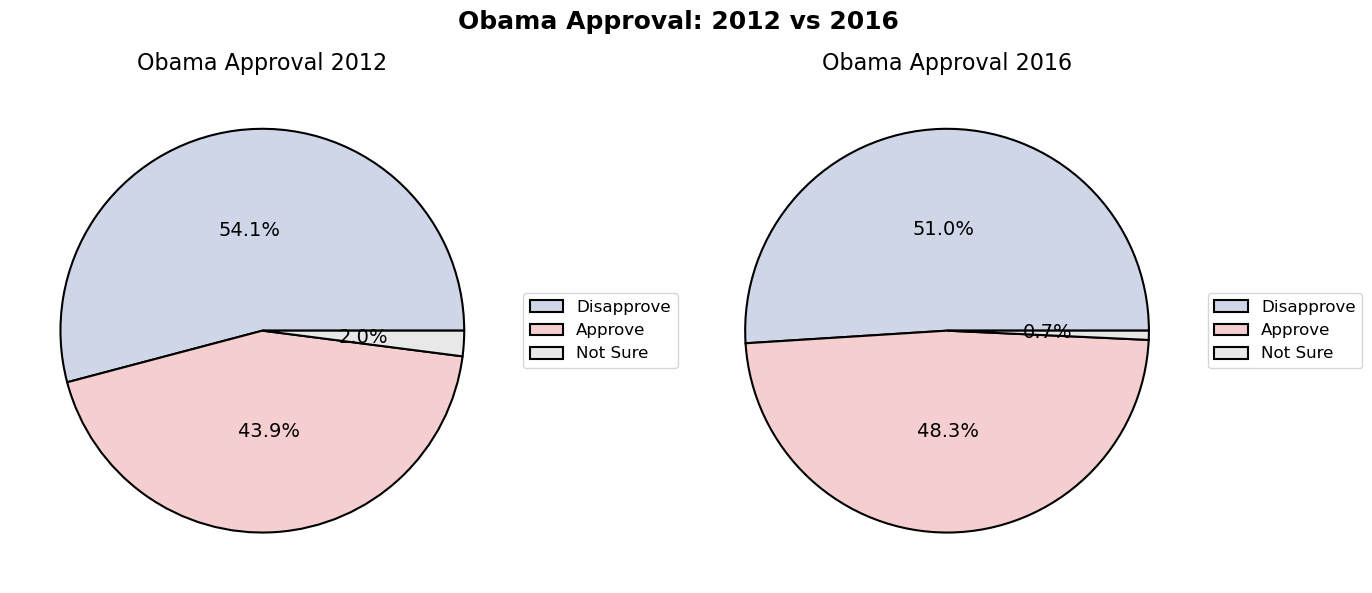

In [2]:
# ── PLOT 1: Obama Approval 2012 vs 2016 (pie charts side by side) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#CED6E8', '#F5CED0', '#E8E8E8']

for ax, col, year in zip([ax1, ax2], ['obama_2012', 'obama_2016'], ['2012', '2016']):
    counts = df_clean[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,
        colors=colors[:len(counts)],
        autopct='%1.1f%%',
        pctdistance=0.5,
        textprops={'fontsize': 14},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
    )
    ax.set_title(f'Obama Approval {year}', fontsize=16)
    ax.legend(wedges, counts.index, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

plt.suptitle('Obama Approval: 2012 vs 2016', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('results/presentation_plots/obama_approval_2012_vs_2016.png', dpi=300, bbox_inches='tight')
plt.show()

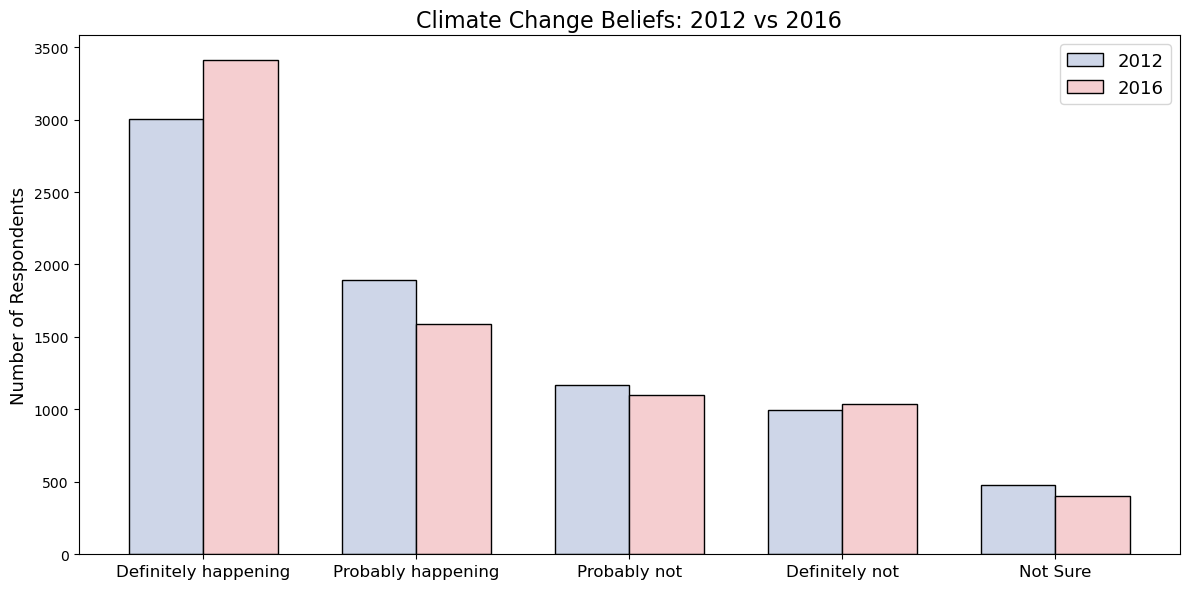

In [3]:
# ── PLOT 2: Environmental Views 2012 vs 2016 (bar chart) ──
order = ['Definitely happening', 'Probably happening', 'Probably not', 'Definitely not', 'Not Sure']
env_colors = ['#2E86AB', '#A8DADC', '#F4A261', '#E63946', '#CCCCCC']

env_2012 = df_clean['env_2012'].value_counts().reindex(order, fill_value=0)
env_2016 = df_clean['env_2016'].value_counts().reindex(order, fill_value=0)

x = range(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width/2 for i in x], env_2012, width, label='2012', color='#CED6E8', edgecolor='black')
ax.bar([i + width/2 for i in x], env_2016, width, label='2016', color='#F5CED0', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=13)
ax.set_title('Climate Change Beliefs: 2012 vs 2016', fontsize=16)
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig('results/presentation_plots/envwarm_2012_vs_2016.png', dpi=300, bbox_inches='tight')
plt.show()

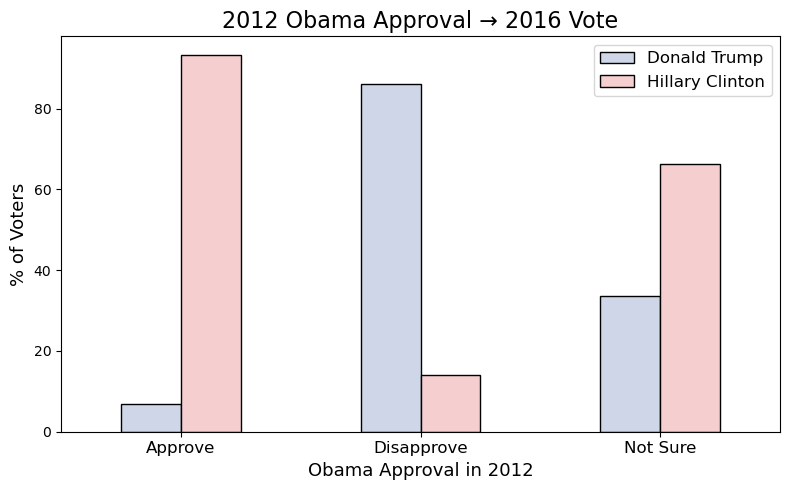

In [7]:
# ── PLOT 3: Obama Approval 2012 → 2016 Vote ──
vote_filter = df_clean['presvote16post_2016'].isin(['Hillary Clinton', 'Donald Trump'])
df_vote = df_clean[vote_filter]

cross = df_vote.groupby(['obama_2012', 'presvote16post_2016']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100  # normalize to %

fig, ax = plt.subplots(figsize=(8, 5))
cross_pct.plot(kind='bar', ax=ax, color=['#CED6E8', '#F5CED0'], edgecolor='black')
ax.set_title('2012 Obama Approval → 2016 Vote', fontsize=16)
ax.set_xlabel('Obama Approval in 2012', fontsize=13)
ax.set_ylabel('% of Voters', fontsize=13)
ax.set_xticklabels(cross_pct.index, rotation=0, fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('results/presentation_plots/obama2012_to_vote2016.png', dpi=300, bbox_inches='tight')
plt.show()